In [1]:

from spm_agent.states.image_analysis_state import AnalysisState
from langgraph.graph import StateGraph, START, END

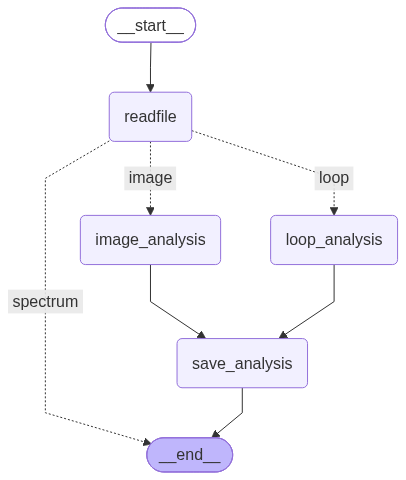

In [2]:
from spm_agent.graphs.analysis_graph import build_analysis_graph

from spm_agent.config import new_run

EXPERIMENT_TASKS = [
    # "Select a diverse measurement set",
    # "Map switching asymmetry across opposite domains",
    # "Compare switching inside domains vs near domain walls",
    # "Study wall-mediated switching"
    # "Investigate the role of domain walls in polarization switching",
    # "Characterize the spatial heterogeneity of switching behavior",
    # "Identify the microstructural origins of switching asymmetry",
    # "Determine the most informative locations for testing competing switching mechanisms",
    # "Investigate how local domain configuration influences polarization switching behavior."
    "Determine how local domain structure affects polarization switching dynamics.",

]

EXPERIMENT_CONTEXT = (
        "This is Dual AC Resonance Tracking (DART) PFM experiment: two drive frequencies f1 and f2 straddle the "
        "contact resonance.  "
        "The sample is lead lanthanum zirconate titanate relazor ferroelectric exhibiting complex domain structures "
        "and heterogeneous polarization-switching behavior.")

im_graph = build_analysis_graph()
im_graph

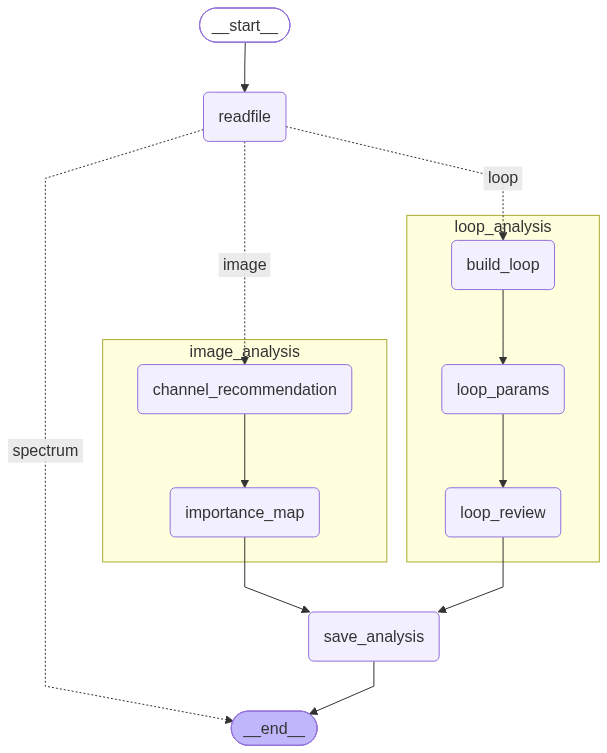

In [3]:
from IPython.display import Image
Image(im_graph.get_graph(xray=True).draw_mermaid_png())

# loops

In [7]:
file_dirs = [
    r"/Users/borisslautin/Desktop/images_for_agents/PLZT_test_loops_1/PZT_loop_test_0001.ibw",
    r"/Users/borisslautin/Desktop/images_for_agents/PLZT_test_loops_1/PZT_loop_test_0002.ibw",
    r"/Users/borisslautin/Desktop/images_for_agents/PLZT_test_loops_1/PZT_loop_test_0003.ibw",
    r"/Users/borisslautin/Desktop/images_for_agents/PLZT_test_loops_1/PZT_loop_test_0004.ibw",
    r"/Users/borisslautin/Desktop/images_for_agents/PLZT_test_loops_1/PZT_loop_test_0005.ibw",
    r"/Users/borisslautin/Desktop/images_for_agents/PLZT_test_loops_1/PZT_loop_test_0006.ibw",
    r"/Users/borisslautin/Desktop/images_for_agents/PLZT_test_loops_1/PZT_loop_test_0007.ibw",
]

In [ ]:
for k, file_dir in enumerate(file_dirs):
        for i in range(10):
            print(new_run(f"plzt_loop_{k}_run{i}")) 
            res = await im_graph.ainvoke({"file_path": file_dir,
                                        "experiment_tasks": EXPERIMENT_TASKS,
                                        "experiment_context": EXPERIMENT_CONTEXT
                                        })

/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/runs/20260823_150705_plzt_loop_6_run0
/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/runs/20260823_150752_plzt_loop_6_run1
/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/runs/20260823_150832_plzt_loop_6_run2
/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/runs/20260823_150907_plzt_loop_6_run3


Process group termination failed for PID 36093: [Errno 1] Operation not permitted, falling back to simple terminate


/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/runs/20260823_151006_plzt_loop_6_run4
/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/runs/20260823_151046_plzt_loop_6_run5
/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/runs/20260823_151124_plzt_loop_6_run6
/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/runs/20260823_151217_plzt_loop_6_run7
/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/runs/20260823_151307_plzt_loop_6_run8
/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/runs/20260823_151356_plzt_loop_6_run9


In [8]:
from spm_agent.config import new_run

print(new_run("baseline"))         
res = await im_graph.ainvoke({
    "file_path": r"/Users/borisslautin/Desktop/images_for_agents/PLZT_ceramics.ibw",
    "experiment_tasks": EXPERIMENT_TASKS,
    "experiment_context": EXPERIMENT_CONTEXT,
})

/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/runs/20260814_170420_baseline


In [9]:
from pprint import pprint

pprint(res['importance_maps'][0]['reasoning'])

('All deliverables are valid. Here is a summary of the criteria chosen and '
 'their physical rationale:\n'
 '\n'
 '---\n'
 '\n'
 '## Criteria Summary\n'
 '\n'
 '### Task: Compare switching inside domains vs near domain walls\n'
 '\n'
 '**Four task criteria** were derived from the DART-PFM channels:\n'
 '\n'
 '1. **`domain_interior`** — Computed as the Euclidean distance from the '
 'nearest domain wall (segmented from smoothed Phase2Retrace, σ=5 px, '
 'threshold at the inter-domain valley ~29°), normalized by the '
 '99th-percentile distance. Pixels far from walls probe **single-domain, '
 'nucleation-limited switching** where the polarization reversal must overcome '
 'the bulk coercive field without wall-mediated assistance — the canonical '
 '"inside domain" measurement site.\n'
 '\n'
 '2. **`domain_wall_proximity`** — Exponential decay from the same wall '
 'skeleton (σ=5 px), giving high scores within ~5–10 pixels of a wall. These '
 'sites probe **wall-pinning, depinning, and n

In [7]:
import json
import textwrap
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


def plot_importance_results(res, task_index=None, save_dir=None, dpi=200):
    """One slide-ready figure per task: component maps, final importance map,
    weights, and the agent's reasoning. `res` = AnalysisState after importance_map_node.

    task_index: int to render one task, None for all.
    save_dir:   if given, saves importance_task_{i}.png there.
    Returns list of figures."""
    entries = res["importance_maps"]
    idxs = range(len(entries)) if task_index is None else [task_index]
    figs = []

    for i in idxs:
        e = entries[i]
        comps = np.load(e["components_path"])                     # (K,H,W)
        final = np.load(e["importance_map_path"])
        meta  = json.loads(Path(e["components_json_path"]).read_text())
        names, weights = meta["names"], np.asarray(meta["weights"], float)
        rationale = meta.get("rationale", [""] * len(names))
        K = comps.shape[0]

        fig = plt.figure(figsize=(4.2 * (K + 1), 8.2))
        gs = GridSpec(2, K + 1, figure=fig, height_ratios=[1.6, 1.0],
                      hspace=0.32, wspace=0.25)

        # --- top row: components + final map ---
        for j in range(K):
            ax = fig.add_subplot(gs[0, j])
            im = ax.imshow(comps[j], cmap="hot", vmin=0, vmax=1)
            ax.set_title(f"C{j+1}: {names[j]}\nw = {weights[j]:.2f}", fontsize=11)
            ax.axis("off")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

        ax = fig.add_subplot(gs[0, K])
        im = ax.imshow(final, cmap="inferno", vmin=0, vmax=100)
        ax.set_title("IMPORTANCE MAP\n(weighted sum)", fontsize=12, fontweight="bold")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        for s in ax.spines.values():
            s.set_visible(True); s.set_linewidth(2)

        # --- bottom left: weights bar chart ---
        axw = fig.add_subplot(gs[1, 0])
        y = np.arange(K)[::-1]
        axw.barh(y, weights, color="#c0392b", alpha=0.85)
        axw.set_yticks(y, [f"C{j+1}" for j in range(K)], fontsize=10)
        axw.set_xlim(0, max(weights) * 1.25)
        for yj, w in zip(y, weights):
            axw.text(w + 0.01, yj, f"{w:.2f}", va="center", fontsize=10)
        axw.set_title("Criteria weights", fontsize=11)
        axw.spines[["top", "right"]].set_visible(False)

        # --- bottom right: text panel ---
        axt = fig.add_subplot(gs[1, 1:])
        axt.axis("off")
        lines = [f"TASK: {e['experiment_task']}", ""]
        for j, (n, r) in enumerate(zip(names, rationale)):
            lines += textwrap.wrap(f"C{j+1} {n}: {r}", 110)
        lines.append("")
        lines += textwrap.wrap("AGENT: " + e.get("reasoning", ""), 110)[:8]  # cap length
        axt.text(0, 1, "\n".join(lines), va="top", ha="left", fontsize=10.5,
                 family="sans-serif", linespacing=1.45, transform=axt.transAxes)

        fig.suptitle(f"Importance map — task {i}", fontsize=14, fontweight="bold", y=0.99)

        if save_dir:
            Path(save_dir).mkdir(parents=True, exist_ok=True)
            fig.savefig(Path(save_dir) / f"importance_task_{i}.png",
                        dpi=dpi, bbox_inches="tight")
        figs.append(fig)

    return figs

In [8]:
%matplotlib inline
plot_importance_results(res)
plt.show()

KeyError: 'weights'

In [ ]:
к